In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from pathlib import Path
import json

from pandas import isna
from scipy.optimize import curve_fit

from algo_metadata import AlgoData, algo_metadata

In [37]:
# df = pd.read_csv("../../../cluster_results/pegasus/final_final_versions_d54c3e0a/uc1_ur10_collision.csv")
df = pd.read_csv("../../../cluster_results/pegasus/final_final_versions_d54c3e0a/complex_env_dual_arm_collision.csv")
# df = pd.read_csv("../../../cluster_results/pegasus/final_final_versions_d54c3e0a/complex_env_dual_arm_collision_max256verts.csv")

# benchmark_file_name_template = lambda i: Path(f"../../data/uc1_ur10_collision/uc1_ur10_collision_{i}.json")
benchmark_file_name_template = lambda i: Path(f"../../data/complex_env_dual_arm_collision/complex_env_dual_arm_collision_{i}.json")
# benchmark_file_name_template = lambda i: Path(f"../../data/complex_env_dual_arm_collision_max256verts/complex_env_dual_arm_collision_max256verts_{i}.json")

df.set_index("file", inplace=True)
df = df.reset_index()  # brings 'file' back as a regular column


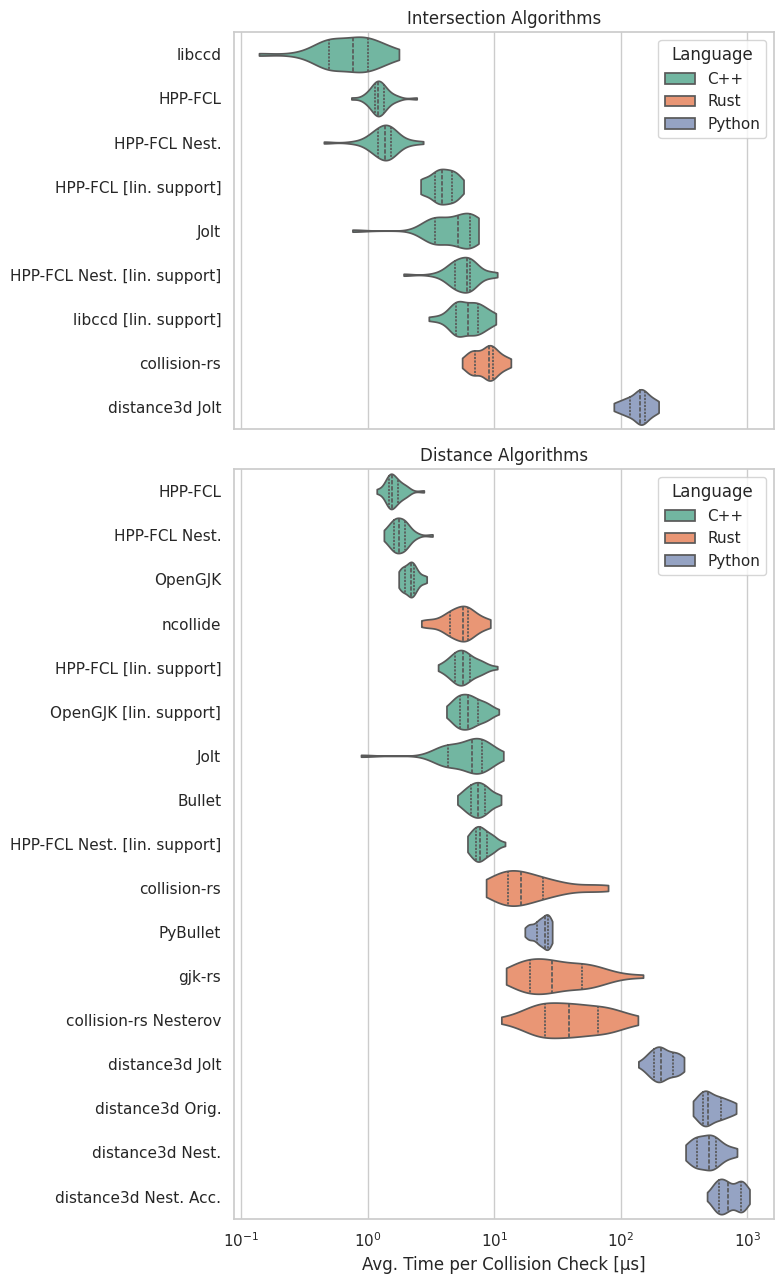

In [38]:
# Violin plot:
sns.set_theme(style="whitegrid")

df_long = df.melt(id_vars='file', var_name='Algorithm', value_name='Value')

# Add metadata columns:
df_long['Language'] = df_long['Algorithm'].map(lambda name: algo_metadata[name].language.value)
df_long['Category'] = df_long['Algorithm'].map(lambda name: algo_metadata[name].category)
df_long['PrettyName'] = df_long['Algorithm'].map(lambda name: algo_metadata[name].pretty_name)


# Add column containing avg. distance between colliders:
def file_to_avg_dist(file_index):
    file_path = benchmark_file_name_template(file_index)
    with open(file_path, "r") as f:
        json_data = json.load(f)
        n_cases_per_test = len(json_data)
        avg_distance = 0
        for case in json_data: avg_distance += case["distance"]
        avg_distance /= n_cases_per_test
    return avg_distance

df_long['AvgDist'] = df_long['file'].map(file_to_avg_dist)


# filter out all entries which exceed min. or max. distances between colliders:
df_long = df_long[(0.0 < df_long['AvgDist']) & (df_long['AvgDist'] < 0.005)]


languages = [lang.value for lang in AlgoData.Language]
lang_colors = sns.color_palette('Set2', n_colors=len(languages))
lang_palette = dict(zip(languages, lang_colors))

categories = [c for c in AlgoData.Category]

n_algos_per_cat = [
    df_long[df_long['Category'] == c]['Algorithm'].nunique()
    for c in categories
]
row_height = 0.5
subplot_heights = [n * row_height for n in n_algos_per_cat]
fig, axes = plt.subplots(
    nrows=len(categories), ncols=1,
    figsize=(8, sum(subplot_heights)),
    sharex=True,
    gridspec_kw={'height_ratios': n_algos_per_cat}
)

for ax, category in zip(axes, categories):
    df_cat = df_long[df_long['Category'] == category]

    # Order the algorithms by median performance:
    order = (
        df_cat.groupby('PrettyName')['Value']
        .median()
        .sort_values(ascending=True)
        .index.tolist()
    )
    cat_languages = df_cat['Language'].unique().tolist()

    sns.violinplot(
        data=df_cat,
        y='PrettyName', x='Value',
        order=order, hue='Language', hue_order=cat_languages,
        palette=lang_palette,
        inner="quart", density_norm="count", log_scale=True, cut=0,
        ax=ax
    )
    ax.set_title(category.value + " Algorithms")
    ax.set_ylabel("")

axes[-1].set_xlabel("Avg. Time per Collision Check [µs]")
plt.tight_layout()
plt.show()

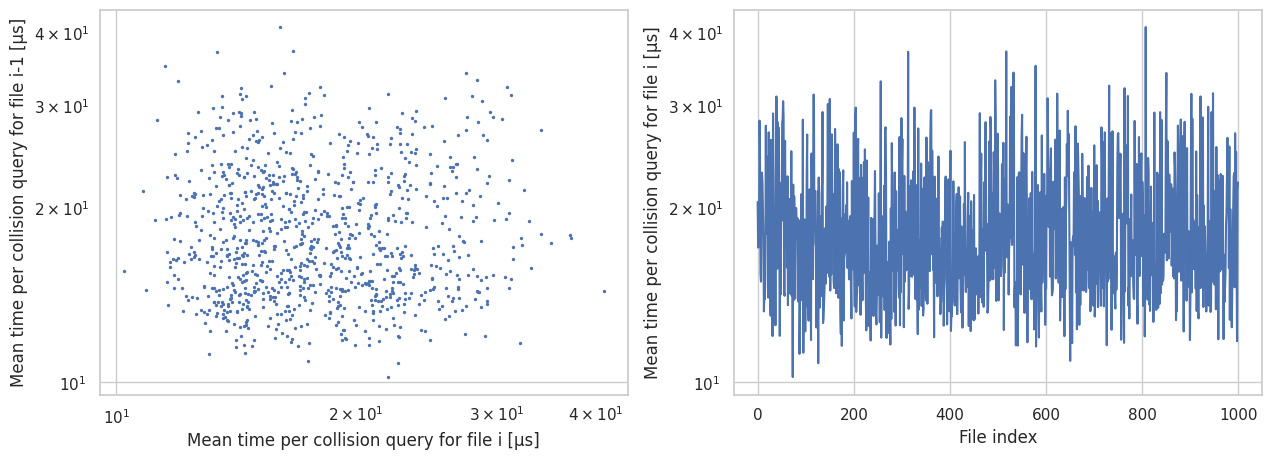

In [39]:
# compute lag plots and show measurements over time:
# values = df["gjk-rs_nasterov_gjk"].dropna().values
values = df["Pybullet"].values

points = []
for i in range(1, len(values)):
    points.append((values[i], values[i-1]))
points = np.array(points)

fix, axes = plt.subplots(1,2, figsize=(15,5))

axes[0].scatter(points[:, 0], points[:, 1], s = 2)
axes[0].set_xlabel("Mean time per collision query for file i [µs]")
axes[0].set_ylabel("Mean time per collision query for file i-1 [µs]")
axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[1].plot(values)
axes[1].set_xlabel("File index")
axes[1].set_ylabel("Mean time per collision query for file i [µs]")
axes[1].set_yscale("log")

plt.show()


In [40]:
colormap = mpl.colormaps["coolwarm"]
# colormap = mpl.colormaps["viridis"]

for curr_algo in df.columns:
    if curr_algo == "file": continue
    values = []

    for index, row in df.iterrows():
        if not pd.isna(row[curr_algo]):
            values.append((int(row["file"]), row[curr_algo]))


    points = []
    for file_index, measurement in values:
        file_path = benchmark_file_name_template(file_index)
        with open(file_path, "r") as f:
            json_data = json.load(f)
            n_cases_per_test = len(json_data)
            avg_distance = 0
            for case in json_data: avg_distance += case["signed_distance"]
            avg_distance /= n_cases_per_test
        points.append((n_cases_per_test, measurement, avg_distance))

    points = np.array(points)

    # normalize the avg_distance field:
    # points[:, 2] /= points[:, 2].max()

    scatter = plt.scatter(points[:, 0], points[:, 1], s = 2, c=points[:,2], cmap=colormap, label="Measurements")
    fig.colorbar(scatter, label="Avg. distance [m]")

    # check if there is a constant overhead per file by trying to fit a 1/x function to the data:

    def func(x, a, b):
        """a represents the constant overhead,
        b represents the mean time per collision query with the overhead removed"""
        return a/x + b

    popt, pcov = curve_fit(func, points[:,0], points[:,1])

    points.sort(axis=0)
    plt.plot(points[:,0], func(points[:,0], *popt), 'r-',
             label='Fit: $y=\\dfrac{%5.3f}{x} + %5.3f$' % tuple(popt), )


    plt.xlabel("Number of cases per file")
    plt.ylabel("Mean time per collision query per file [µs]")
    plt.legend(loc="upper right")
    plt.title(algo_metadata[curr_algo].pretty_name_full)
    plt.yscale("log")
    plt.show()

KeyError: 'signed_distance'